In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset (3).csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [2]:
# Impute missing values using group medians
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('median'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby('Season')['Soil_Moisture_pct'].transform('median'))
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].transform('median'))

print("Remaining missing values:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Remaining missing values:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


/tmp/ipykernel_1059/2444117799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator=np.mean, errorbar=None, palette='Blues_d')


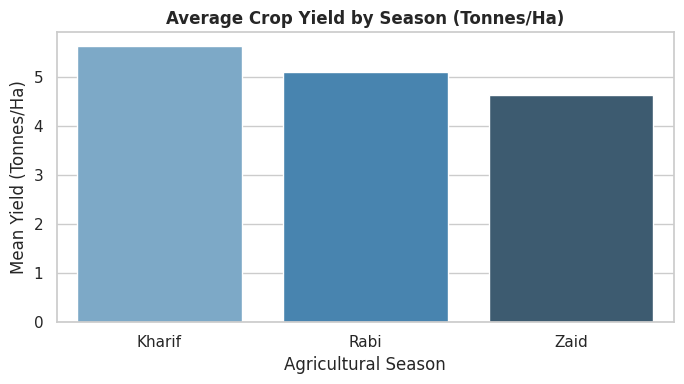

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator=np.mean, errorbar=None, palette='Blues_d')
plt.title('Average Crop Yield by Season (Tonnes/Ha)', fontsize=12, fontweight='bold')
plt.xlabel('Agricultural Season')
plt.ylabel('Mean Yield (Tonnes/Ha)')
plt.savefig('chart1_seasonal_yield.png', dpi=300)
plt.show()

/tmp/ipykernel_1059/1792135327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Pastel1', showfliers=False)


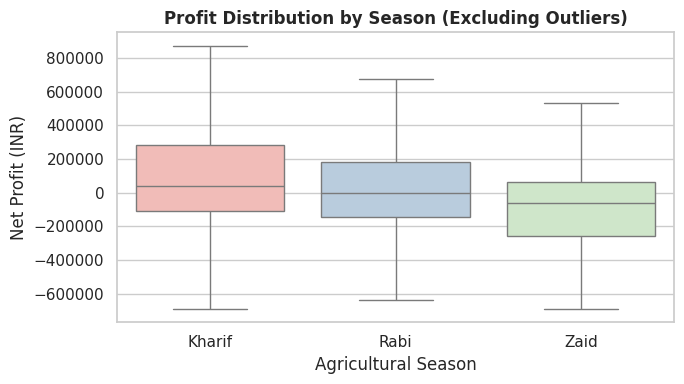

In [4]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Pastel1', showfliers=False)
plt.title('Profit Distribution by Season (Excluding Outliers)', fontsize=12, fontweight='bold')
plt.xlabel('Agricultural Season')
plt.ylabel('Net Profit (INR)')
plt.savefig('chart2_profit_distribution.png', dpi=300)
plt.show()

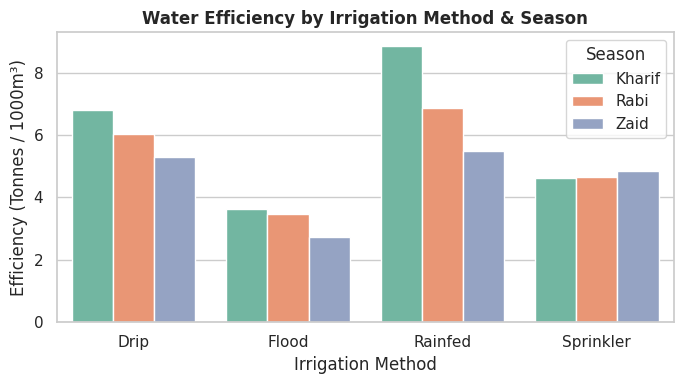

In [5]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', errorbar=None, palette='Set2')
plt.title('Water Efficiency by Irrigation Method & Season', fontsize=12, fontweight='bold')
plt.xlabel('Irrigation Method')
plt.ylabel('Efficiency (Tonnes / 1000m³)')
plt.savefig('chart3_irrigation_efficiency.png', dpi=300)
plt.show()

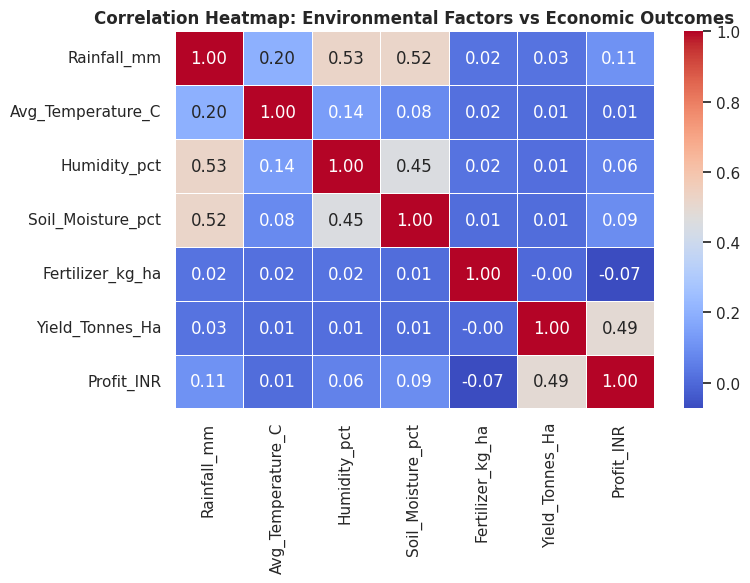

In [6]:
plt.figure(figsize=(8, 6))
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct', 'Fertilizer_kg_ha', 'Yield_Tonnes_Ha', 'Profit_INR']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Environmental Factors vs Economic Outcomes', fontsize=12, fontweight='bold')
plt.savefig('chart4_correlation_heatmap.png', dpi=300)
plt.show()

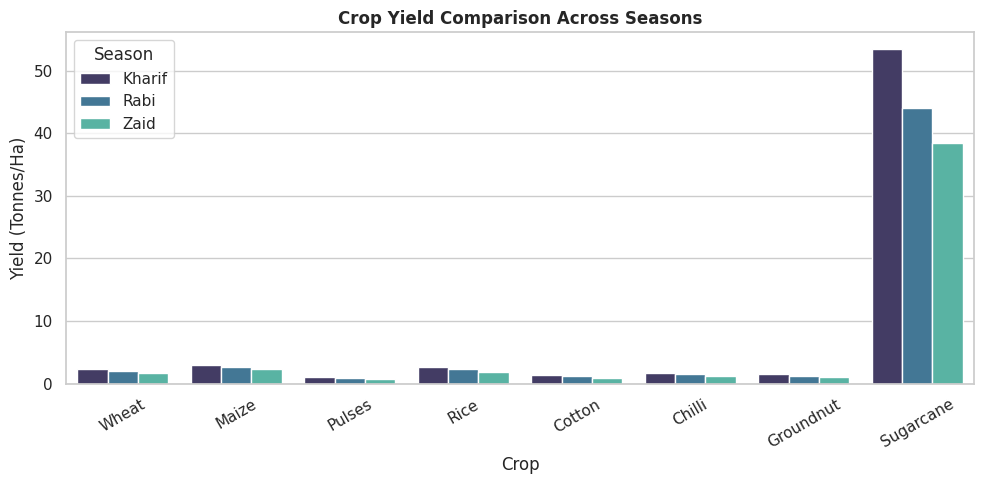

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', errorbar=None, palette='mako')
plt.title('Crop Yield Comparison Across Seasons', fontsize=12, fontweight='bold')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=30)
plt.savefig('chart5_crop_seasonal_yield.png', dpi=300)
plt.show()

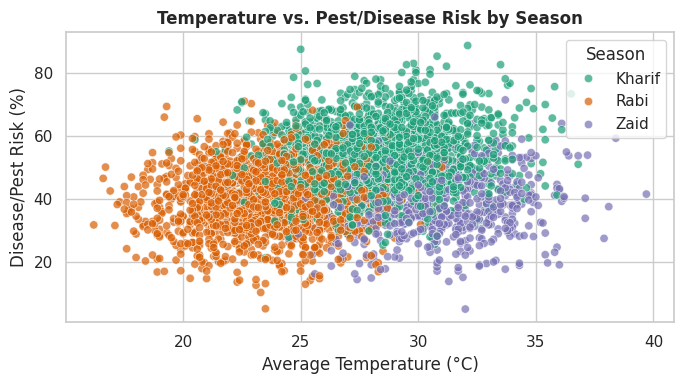

In [8]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Disease_Pest_Risk_pct', hue='Season', palette='Dark2', alpha=0.7)
plt.title('Temperature vs. Pest/Disease Risk by Season', fontsize=12, fontweight='bold')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Disease/Pest Risk (%)')
plt.savefig('chart6_temp_pest_risk.png', dpi=300)
plt.show()

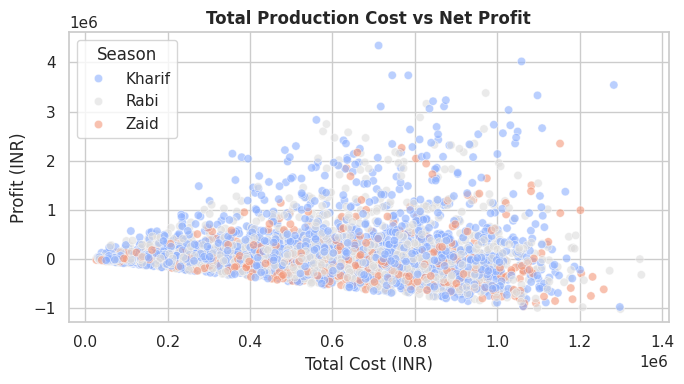

In [9]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Total_Cost_INR', y='Profit_INR', hue='Season', palette='coolwarm', alpha=0.6)
plt.title('Total Production Cost vs Net Profit', fontsize=12, fontweight='bold')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Profit (INR)')
plt.savefig('chart7_cost_vs_profit.png', dpi=300)
plt.show()